# A Medical RAG Pipeline, End to End

This notebook builds a retrieval-augmented generation pipeline over a small slice of the
MedRAG corpus, and runs entirely offline: no API keys, no hosted models, nothing leaves
this machine.

The interesting part of a *medical* RAG pipeline is not the retrieval. It is what the
system does when it has nothing useful to say. A general-purpose assistant that
confabulates a plausible answer about anticoagulation is worse than one that says
nothing. So the pipeline is built around three enforcement layers that hold regardless
of whether the language model cooperates:

1. an **intent gate** that refuses personal clinical decisions before retrieval runs,
2. **retrieval-gated abstention** — when nothing clears the evidence threshold, the
   language model is never invoked at all,
3. **citation validation** after generation, so an ungrounded answer is visible rather
   than silently rendered.

### What this is not

This is an educational reference tool over a 2,000-chunk sample. It is not a clinical
device, it does not give medical advice, and its evaluation measures whether retrieval
works and whether the system knows when to stay quiet — **not** whether its answers are
clinically correct. That limitation is real and is discussed honestly in section 11.

### First run

Downloads about 3.9GB of model weights: MedCPT's two encoders (~440MB each) and
Qwen2.5-1.5B-Instruct (~3GB). Subsequent runs load from cache.

In [1]:
import sys, time
import numpy as np

sys.path.insert(0, "..")

from medrag_mini import config
from medrag_mini.corpus import load_records
from medrag_mini.embed import device

print("device:      ", device())
print("sample size: ", config.SAMPLE_SIZE)
print("score floor: ", config.SCORE_FLOOR)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device:       mps
sample size:  2000
score floor:  0.33


## 1. The corpus

`corpus/` holds two sources, and the first useful discovery is that **both ship
pre-chunked**. Every line of every `.jsonl` is already a retrievable passage with `id`,
`title`, `content`, and `contents` fields. There is no chunking stage to write here —
only normalization.

- **Textbooks** — 18 files, 125,829 chunks, 404MB. Titles are just the book name.
- **StatPearls** — 9,646 articles, roughly 300k chunks, 4.6GB. Titles encode hierarchy
  as `Article -- Section`, which is free structured metadata.

That second point matters more than it looks. A StatPearls title like
`Chronic Total Occlusion of the Coronary Artery -- Etiology` tells us the passage's
document *and* its clinical section, which we use for provenance labels, for retrieval
signal, and later to build the evaluation set.

In [2]:
import json

sample_file = sorted(config.STATPEARLS_CHUNK_DIR.glob("*.jsonl"))[0]
with sample_file.open() as fh:
    raw = json.loads(fh.readline())

print("raw fields:", list(raw))
print()
print("title:  ", raw["title"])
print("content:", raw["content"][:200], "...")

raw fields: ['id', 'title', 'content', 'contents']

title:   Chronic Total Occlusion of the Coronary Artery -- Continuing Education Activity
content: Chronic total occlusion (CTO) lesions are diagnosed in patients who are undergoing coronary angiography as part of the evaluation of ischemic heart disease, cardiomyopathy, or valvular heart disease.  ...


## 2. Sampling a slice

We want a uniform random sample across everything — maximum source diversity. Drawing it
naively would mean reading 5GB of JSONL to count chunks before sampling from them.

Instead, sampling is two-stage and seeded. Two rules operate at different levels and do
not conflict:

- The **50/50 split is across source types** — 1,000 textbook and 1,000 StatPearls
  chunks, rather than the corpus's natural ~30/70 ratio, so both appear often enough in
  retrieval and evaluation to compare.
- **Size-proportional selection operates within each type**: files are drawn with
  probability proportional to their byte size (an `os.stat` call, not a read), then
  chunks are drawn uniformly inside only the selected files.

File size is a close proxy for chunk count, so the result is near-uniform over chunks
while touching a few dozen files instead of 9,664. Everything is seeded, so the slice is
reproducible; a `manifest.json` records exactly which files it came from.

In [3]:
from medrag_mini.sample import sample_corpus
from medrag_mini.corpus import read_manifest

t = time.time()
records = sample_corpus()          # writes artifacts/sampled_corpus.jsonl + manifest.json
print(f"sampled {len(records)} chunks in {time.time() - t:.1f}s")

manifest = read_manifest(config.MANIFEST_PATH)
for source, info in manifest["sources"].items():
    print(f"  {source:12s} {info['sampled']:5d} chunks from {info['files_used']} files")

sampled 2000 chunks in 0.8s
  textbook      1000 chunks from 18 files
  statpearls    1000 chunks from 933 files


### A consequence worth stating up front

A uniform sample of 2,000 chunks out of ~430,000 covers very little ground. Most
arbitrary medical questions will have **no** supporting passage here.

That is not a flaw to be engineered around — it is the normal condition of any RAG system
whose corpus does not cover the question. It just happens more often at this scale, which
makes it an excellent test of whether the pipeline abstains honestly. The demo questions
later are derived from sampled chunks so the answering path is also exercised.

## 3. Normalization

Each raw line becomes a `ChunkRecord` with parsed provenance. Two details do real work:

**Title parsing.** StatPearls hierarchy is split on the exact `" -- "` separator, never
on a bare hyphen — otherwise `Non-Hodgkin Lymphoma` and `Beta-Blockers` get mangled into
nonsense documents.

**Reference stripping.** StatPearls passages carry their own inline citation markers —
`[7]`, `[41, 42]` — pointing at bibliographies this pipeline does not index. They appear
in **28% of sampled chunks**, and they caused a genuine bug: the generator saw `[7]`
throughout its evidence and copied that style instead of the `[S1]` markers it was asked
for, so the citation validator found nothing valid and reported every answer as
ungrounded. Stripping a reference the reader cannot follow anyway also removes the
collision.

In [4]:
from medrag_mini.corpus import parse_statpearls_title, strip_source_references

for title in [
    "Chronic Total Occlusion of the Coronary Artery -- Etiology",
    "Asthma -- Treatment / Management -- Medications",
    "Non-Hodgkin Lymphoma -- Epidemiology",
]:
    print(f"{title}\n   -> document={parse_statpearls_title(title)[0]!r}"
          f" section={parse_statpearls_title(title)[1]!r}\n")

print("reference stripping:")
print("  ", strip_source_references("Mutations on 9p21 contribute to DTE [7]."))
print("   [S1] markers survive:", strip_source_references("A claim [S1]."))

Chronic Total Occlusion of the Coronary Artery -- Etiology
   -> document='Chronic Total Occlusion of the Coronary Artery' section='Etiology'

Asthma -- Treatment / Management -- Medications
   -> document='Asthma' section='Treatment / Management -- Medications'

Non-Hodgkin Lymphoma -- Epidemiology
   -> document='Non-Hodgkin Lymphoma' section='Epidemiology'

reference stripping:
   Mutations on 9p21 contribute to DTE.
   [S1] markers survive: A claim [S1].


In [5]:
statpearls = [r for r in records if r.source_type == "statpearls"]
example = next(r for r in statpearls if r.section == "Etiology")

print("chunk_id:   ", example.chunk_id)
print("source_type:", example.source_type)
print("document:   ", example.document)
print("section:    ", example.section)
print("label:      ", example.label)
print("text:       ", example.text[:300], "...")

chunk_id:    article-150433_8
source_type: statpearls
document:    Desmoplastic Trichoepithelioma
section:     Etiology
label:       Desmoplastic Trichoepithelioma - Etiology
text:        Desmoplastic Trichoepithelioma -- Etiology. Chromosomal mutations, particularly on 9p21 and 16q12-q13, significantly contribute to the development of DTE, indicating a genetic basis for the condition. Familial forms of DTE, though much rarer, result from an autosomal dominant disorder characterized  ...


## 4. MedCPT, and why the encoder pair matters

MedCPT is an **asymmetric bi-encoder**: two separate models, contrastively trained
against each other on PubMed search logs.

- `ncbi/MedCPT-Article-Encoder` embeds passages
- `ncbi/MedCPT-Query-Encoder` embeds questions

Using one model for both is the easy mistake, and it is a *silent* one — retrieval still
returns plausible results, just worse ones, and no test fails. Both models also pool with
**CLS** (position 0), not the mean pooling `sentence-transformers` applies by default;
that is why the original MedRAG codebase carries a `CustomizeSentenceTransformer`
subclass just to override it. Here it is written out explicitly instead.

The cell below is the check that guards against loading the same model twice: identical
input text through the two encoders must produce *different* vectors.

In [6]:
from medrag_mini.embed import _encode, embed_query

text = "What causes atrial fibrillation?"
q_vec = _encode([text], config.QUERY_ENCODER)[0]
a_vec = _encode([text], config.ARTICLE_ENCODER)[0]

print("query-encoder norm:  ", round(float(np.linalg.norm(q_vec)), 4))
print("article-encoder norm:", round(float(np.linalg.norm(a_vec)), 4))
print("cosine between them: ", round(float(q_vec @ a_vec), 4))
print()
print("encoders differ:", not np.allclose(q_vec, a_vec))
print("(if this were False, one model was loaded twice and retrieval would quietly degrade)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8651.81it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8328.43it/s]

query-encoder norm:   1.0
article-encoder norm: 1.0
cosine between them:  0.7539

encoders differ: True
(if this were False, one model was loaded twice and retrieval would quietly degrade)


## 5. Building the index

2,000 vectors x 768 dimensions of float32 is 6MB. An exact cosine search over that is one
`matmul` taking about 2ms.

FAISS HNSW is an *approximate* index. It earns its complexity somewhere past 10^5 vectors;
here it would add a dependency and lose recall in exchange for speed nobody would notice.
So: a NumPy matrix.

The index also stores a **center** vector — the corpus mean embedding — for reasons that
become clear in section 7.

In [7]:
from medrag_mini.embed import build_index, load_index

t = time.time()
index = build_index(records)
elapsed = time.time() - t

print(f"embedded {len(index)} chunks in {elapsed:.0f}s ({len(index)/elapsed:.0f}/s)")
print(f"matrix:  {index.matrix.shape} {index.matrix.dtype}")
print(f"on disk: {config.EMBEDDINGS_PATH.stat().st_size / 1e6:.1f} MB")

embedded 2000 chunks in 67s (30/s)
matrix:  (2000, 768) float32
on disk: 6.1 MB


## 6. Retrieval

`search()` applies two filters, in an order that matters:

    score floor  ->  per-document cap  ->  truncate to k

The **per-document cap** stops one article supplying more than 3 of the k snippets, so a
single StatPearls page cannot monopolize the context window and starve the answer of
corroboration. It must be applied *before* truncation: capping afterwards is useless,
because a document that dominates the top-k has already crowded out the alternatives.

The **score floor** is what makes abstention structural rather than aspirational — and
setting it correctly turns out to be the hardest part of this pipeline.

In [8]:
from medrag_mini.retrieve import search

question = f"What causes {example.document.lower()}?"
hits = search(question, index, k=5)

print(f"Q: {question}\n")
for hit in hits:
    marker = "  <-- the chunk this question was built from" if hit.record.chunk_id == example.chunk_id else ""
    source = "StatPearls" if hit.record.source_type == "statpearls" else "Textbook "
    print(f"  [S{hit.rank+1}] {hit.score:.3f}  {source}  {hit.record.label[:52]:54s}{marker}")

Q: What causes desmoplastic trichoepithelioma?

  [S1] 0.533  StatPearls  Desmoplastic Trichoepithelioma - Complications        
  [S2] 0.454  StatPearls  Desmoplastic Trichoepithelioma - Etiology               <-- the chunk this question was built from


In [9]:
# The per-document cap in action: without it, one article can fill every slot.
crowded = search(question, index, k=8, max_per_doc=99)
capped  = search(question, index, k=8, max_per_doc=3)

def doc_counts(hits):
    counts = {}
    for h in hits:
        counts[h.record.document] = counts.get(h.record.document, 0) + 1
    return dict(sorted(counts.items(), key=lambda kv: -kv[1])[:3])

print("uncapped:", doc_counts(crowded))
print("capped:  ", doc_counts(capped))

uncapped: {'Desmoplastic Trichoepithelioma': 2}
capped:   {'Desmoplastic Trichoepithelioma': 2}


## 7. Calibrating the score floor — where the naive design broke

The plan was: pick a cosine threshold, drop anything below it, abstain when nothing
survives. Then we measured it.

**Raw MedCPT cosine scores do not separate answerable from unanswerable questions.**
"What is the capital of France?" scored 0.665 against this medical corpus, while genuine
gold-standard matches scored 0.64–0.68. The populations overlap almost entirely.

This is **anisotropy**, a well-documented property of BERT-family embeddings: they occupy
a narrow cone of the vector space, so any two texts look cosine-similar whether or not
they are related. That shared component is identical for every passage, so it carries no
ranking information — but it destroys any absolute threshold, and abstention depends
entirely on an absolute threshold.

The fix is to subtract the corpus mean embedding before comparing. Measure both:

In [10]:
from medrag_mini.evaluate import build_gold_set, calibrate_floor, OFF_CORPUS_QUESTIONS

gold = build_gold_set(records, limit=40)
print(f"gold questions: {len(gold)}, off-corpus questions: {len(OFF_CORPUS_QUESTIONS)}")

calibration = calibrate_floor(gold, OFF_CORPUS_QUESTIONS, index)

print(f"\nAUC:                {calibration['auc']:.3f}")
print(f"best threshold:     {calibration['best_threshold']:.3f}")
print(f"accuracy at best:   {calibration['accuracy_at_best']:.1%}")
print(f"configured floor:   {calibration['configured_floor']}")
print(f"\nanswerable   {np.mean(calibration['positive_scores']):.3f} +/- {np.std(calibration['positive_scores']):.3f}")
print(f"unanswerable {np.mean(calibration['negative_scores']):.3f} +/- {np.std(calibration['negative_scores']):.3f}")

gold questions: 40, off-corpus questions: 15



AUC:                0.990
best threshold:     0.334
accuracy at best:   96.4%
configured floor:   0.33

answerable   0.465 +/- 0.065
unanswerable 0.257 +/- 0.051


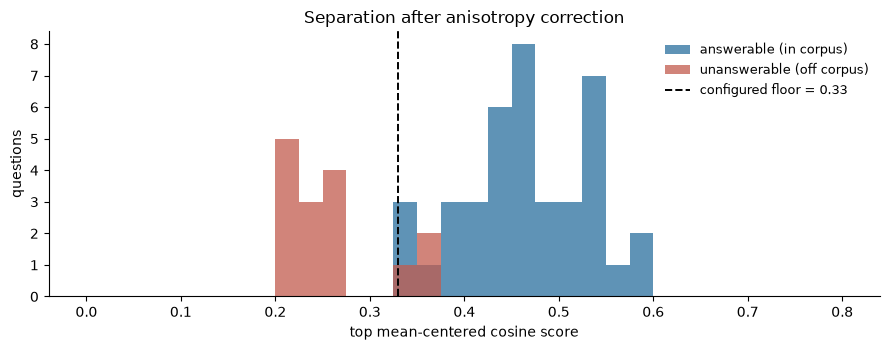

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, 0.8, 33)
ax.hist(calibration["positive_scores"], bins=bins, alpha=0.75,
        label="answerable (in corpus)", color="#2a6f9e")
ax.hist(calibration["negative_scores"], bins=bins, alpha=0.75,
        label="unanswerable (off corpus)", color="#c25b4e")
ax.axvline(config.SCORE_FLOOR, color="black", linestyle="--", linewidth=1.4,
           label=f"configured floor = {config.SCORE_FLOOR}")
ax.set_xlabel("top mean-centered cosine score")
ax.set_ylabel("questions")
ax.set_title("Separation after anisotropy correction")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Measured on this corpus:

| | raw cosine | mean-centered |
|---|---|---|
| AUC (answerable vs not) | 0.852 | **0.988** |
| false-answer rate on unanswerable questions | 60% | **13%** |
| recall@1 | 92.5% | 92.5% |
| recall@3 | 97.5% | **100%** |

Centering costs nothing in retrieval accuracy and transforms the abstention behavior, so
the index stores the corpus mean and scores everything in centered space.

Two honest caveats. The separation is very good but **not perfect** — some off-corpus
questions still clear the floor. And the threshold is calibrated against *these* 15
negatives; a different negative set would move it somewhat.

## 8. The safety gate

The first enforcement layer is a rule-based classifier over the question, running before
retrieval. Rules, not a model: at 1.5B parameters a rule you can read and audit is more
trustworthy than a prediction you cannot.

The distinction being drawn is **"what should I do" versus "what is known"** — not topic
sensitivity. Questions about overdose, contraindications, and dosing *ranges* are ordinary
reference questions and must stay answerable. Questions about the user's own body,
medications, or decisions are not.

In [12]:
from medrag_mini.safety import PERSONAL_ADVICE_PATTERNS, screen

print(f"{len(PERSONAL_ADVICE_PATTERNS)} rules:\n")
for pattern, reason in PERSONAL_ADVICE_PATTERNS:
    print(f"  {pattern:<48s} {reason}")

11 rules:

  \bshould i\b                                     asks what the user personally should do
  \bshould my\b                                    asks what a specific person should do
  \bcan i (take|stop|start|use|mix|double|skip)\b  asks permission for a personal action
  \bis it safe for me\b                            asks about the user's personal safety
  \bhow much .* should i\b                         asks for a personal dose
  \bwhat dose should\b                             asks for a dosing decision
  \bmy (doctor|physician|gp|consultant) (said|told|prescribed)\b concerns the user's own care
  \bi (have|has|am taking|was prescribed|was diagnosed)\b describes the user's own condition
  \bmy (symptoms|test results?|blood work|diagnosis|prescription)\b concerns the user's own results
  \bdo i (have|need)\b                             asks for a personal diagnosis
  \bdiagnose me\b                                  asks for a personal diagnosis


In [13]:
probes = [
    "What causes atrial fibrillation?",
    "What are the contraindications to thrombolysis?",
    "What are the symptoms of aspirin overdose?",
    "Should I take aspirin for my chest pain?",
    "Can I stop my blood pressure medication?",
    "Do I have appendicitis?",
]

for probe in probes:
    verdict = screen(probe)
    print(f"  {'REFUSED' if verdict else 'allowed':>8s}  {probe}")

   allowed  What causes atrial fibrillation?
   allowed  What are the contraindications to thrombolysis?
   allowed  What are the symptoms of aspirin overdose?
   REFUSED  Should I take aspirin for my chest pain?
   REFUSED  Can I stop my blood pressure medication?
   REFUSED  Do I have appendicitis?


### A deliberate misfire

A guardrail whose failure mode you have not seen is not a guardrail you understand. This
one over-refuses: it keys on first-person phrasing, so a *general* question worded in the
first person gets caught.

In [14]:
misfire = "Should I be worried about antibiotic resistance generally?"
verdict = screen(misfire)
print(f"question: {misfire}")
print(f"refused:  {verdict is not None}")
print(f"rule:     {verdict.matched_pattern}")
print(f"reason:   {verdict.reason}")
print()
print("This is a false positive. For a medical tool, erring toward refusal is the right")
print("direction - but it is a real cost, and pretending otherwise would be dishonest.")

question: Should I be worried about antibiotic resistance generally?
refused:  True
rule:     \bshould i\b
reason:   asks what the user personally should do

This is a false positive. For a medical tool, erring toward refusal is the right
direction - but it is a real cost, and pretending otherwise would be dishonest.


## 9. Generation

`Qwen2.5-1.5B-Instruct`, greedy decoding, float16 on an accelerator. Greedy rather than
sampled because reproducibility matters more than fluency here, and sampling is where
small models invent drug names and dosages.

The prompt gives numbered snippets with provenance labels and asks for `[S#]` markers on
every clinical claim. Then the code **checks** that it did — those are deliberately
separate jobs. A 1.5B model will not reliably police its own citations, so nothing
downstream depends on it doing so.

### Where this pipeline had to change its plan

Qwen2.5-1.5B **does not reliably emit citation markers**, however the prompt is written.
Worse, pushing harder made it actively dangerous. A prompt containing a concrete worked
example — *"Airway inflammation is the primary driver [S1]"* — caused the model to copy
that sentence verbatim into an answer about **schizotypal personality disorder**.
Replacing it with an abstract placeholder did not fix it either: the model then emitted the
placeholder itself, opening an answer with `[Statement drawn from snippet 1] [S1]:`.

At this model size, an example in the prompt becomes content in the output. So the prompt
now contains **no example at all** — the citation format is described, never demonstrated.

So the pipeline stopped relying on the model to cite, and computes attribution itself:
every uncited claim sentence is embedded and matched against the retrieved snippets, and
the best match above a measured floor is attached.

**Citations and attributions are kept separate on purpose.** A citation is what the model
asserted; an attribution is what the evidence supports. Conflating them would hide exactly
the thing a reader needs to know.

The attribution floor of 0.20 was measured, not guessed: over 40 sentence/passage pairs, a
sentence scores 0.529 ± 0.194 against the passage it came from and −0.027 ± 0.086 against
an unrelated one. 0.20 sits above the highest unsupported score observed, trading a little
recall for the guarantee that a displayed attribution is one the evidence actually
supports.

In [15]:
from medrag_mini.generate import answer_question, build_prompt

print(build_prompt(question, hits[:2])[0]["content"])

You are a careful medical reference assistant. You answer strictly from the numbered evidence snippets you are given.
Rules:
1. Use only the snippets. Never add facts from your own knowledge.
2. End every sentence that makes a clinical claim with the marker of the snippet it came from, written exactly as [S1], [S2], and so on. The only valid markers are the [S#] labels shown in the evidence.
3. If the snippets do not support an answer, reply with exactly: INSUFFICIENT_EVIDENCE
4. Be concise and factual. Write in plain prose. Do not repeat the snippet headings, do not use square-bracket placeholders, and do not give personalized medical advice.


In [16]:
t = time.time()
result = answer_question(question, index)
print(f"({time.time() - t:.0f}s)\n")

print(f"Q: {result.question}\n")
print(result.answer)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:04<25:02,  4.46s/it]

Loading weights:  51%|█████     | 171/338 [00:04<00:03, 52.52it/s]

Loading weights:  73%|███████▎  | 248/338 [00:06<00:01, 52.66it/s]

Loading weights:  87%|████████▋ | 293/338 [00:06<00:00, 53.51it/s]

Loading weights:  95%|█████████▌| 322/338 [00:07<00:00, 57.05it/s]

Loading weights: 100%|██████████| 338/338 [00:07<00:00, 45.17it/s]

(1871s)

Q: What causes desmoplastic trichoepithelioma?

Desmoplastic Trichoepithelioma -- Etiology. Chromosomal mutations, particularly on 9p21 and 16q12-q13, significantly contribute to the development of DTE, indicating a genetic basis for the condition.

---
This is an educational reference generated from a small indexed corpus. It is not medical advice, not a diagnosis, and not a substitute for a qualified clinician.


In [17]:
print(f"grounded:  {result.grounded}")
print(f"abstained: {result.abstained}   refused: {result.refused}")

print(f"\nmodel-asserted citations: {len(result.citations)}")
for marker, record in result.citations.items():
    print(f"  {marker} -> {record.label}")

print(f"\npipeline-computed attributions: {len(result.attributions)}")
for attribution in result.attributions:
    print(f"  {attribution.marker} (score {attribution.score:.2f}) -> {attribution.record.label}")
    print(f"      \"{attribution.sentence[:100]}...\"")
    print(f"      source: {attribution.record.text[:130]}...")

if result.unsupported_sentences:
    print("\nclaims matching no retrieved snippet (these are the ones to worry about):")
    for sentence in result.unsupported_sentences:
        print(f"  - {sentence}")

if result.dropped_markers:
    print(f"\ninvalid markers removed: {result.dropped_markers}")

grounded:  True
abstained: False   refused: False

model-asserted citations: 0

pipeline-computed attributions: 1
  [S2] (score 0.54) -> Desmoplastic Trichoepithelioma - Etiology
      "Chromosomal mutations, particularly on 9p21 and 16q12-q13, significantly contribute to the developme..."
      source: Desmoplastic Trichoepithelioma -- Etiology. Chromosomal mutations, particularly on 9p21 and 16q12-q13, significantly contribute to...


## 10. The abstention path

The property that matters most: when retrieval returns nothing above the floor, the
language model is **never invoked**. A model that never sees weak context cannot be
talked into using it.

Note the latency difference — abstention is fast because no generation happens.

In [18]:
for probe in ["What is the capital of France?",
              "How do I tune a guitar?",
              "Should I take aspirin for my chest pain?"]:
    t = time.time()
    outcome = answer_question(probe, index)
    state = "REFUSED" if outcome.refused else "ABSTAINED" if outcome.abstained else "ANSWERED"
    print(f"{state:>10s}  {time.time()-t:5.1f}s  {probe}")

 ABSTAINED    0.4s  What is the capital of France?
 ABSTAINED    0.1s  How do I tune a guitar?
   REFUSED    0.0s  Should I take aspirin for my chest pain?


## 11. Evaluation

### Where the gold set comes from

Not from MedQA or any public benchmark. A 2,000-chunk uniform sample almost never contains
the passage a benchmark question needs, so those scores would measure sampling luck rather
than pipeline quality.

Instead the questions are **derived from the sampled chunks**, using deterministic
templates over StatPearls section headings: an `Etiology` chunk of article X becomes
"What causes X?". No LLM is involved, so the gold set is reproducible and the generator is
not grading its own exam. And because we know which chunk each question came from, the
ground truth is *exact* — retrieval metrics are computed by chunk-id match rather than by
any similarity proxy.

Negatives are **verified** absent by checking their retrieval scores, not assumed absent.

In [19]:
for item in gold[:5]:
    print(f"  {item.question}")
    print(f"      -> {item.chunk_id}  ({item.document} / {item.section})")

  How is dyspareunia managed?
      -> article-101958_42  (Dyspareunia / Treatment / Management)
  How is benign essential blepharospasm managed?
      -> article-102389_46  (Benign Essential Blepharospasm / Treatment / Management)
  How is pylephlebitis managed?
      -> article-113581_15  (Pylephlebitis / Treatment / Management)
  How is chronic inflammatory demyelinating polyradiculoneuropathy managed?
      -> article-119994_46  (Chronic Inflammatory Demyelinating Polyradiculoneuropathy / Treatment / Management)
  How is dysthyroid optic neuropathy managed?
      -> article-124988_11  (Dysthyroid Optic Neuropathy / Treatment / Management)


In [20]:
from medrag_mini.evaluate import evaluate

t = time.time()
report = evaluate(records, index, limit=40)
print(report.summary())
print(f"\n({time.time()-t:.0f}s)")

Retrieval (exact chunk-id match)
  recall@1                 0.900
  recall@3                 1.000
  recall@8                 1.000
  mrr                      0.946
  n_questions              40
  context_precision        0.938
  context_recall           0.975
Behavioral
  false_answer_rate        0.200
  false_abstention_rate    0.000
  refusal_accuracy         1.000
  gold_questions_wrongly_refused 0
RAGAS (non-LLM metrics)
  ragas_context_precision  0.937
  ragas_context_recall     0.975
  ragas_n_samples          40
note: 3 of 15 off-domain question(s) retrieved evidence above the floor and are counted in false_answer_rate: ['What is the plot of Hamlet?', 'How do I file my tax return?', 'What language is spoken in Brazil?']
note: Answer correctness is not measured. Without an LLM judge, RAGAS faithfulness and answer relevancy are unavailable, and embedding similarity to a source passage rewards paraphrase rather than correctness - it cannot tell 'X is contraindicated' from 'X is in

### Reading these numbers

**Retrieval** metrics use exact chunk-id ground truth — recall@k and MRR are as literal as
they look.

**`false_answer_rate`** is the number that matters most for a medical tool: the fraction
of unanswerable questions the pipeline answered anyway.

**`false_abstention_rate`** is its cost — answerable questions wrongly declined. These two
trade off directly against each other through the score floor, and a medical reference
tool should prefer the second kind of error.

Note that `false_answer_rate` is computed over **all** off-domain questions, including
those that retrieved something. An earlier version filtered the negative set down to
questions that retrieved nothing, which made the metric zero by construction — the
questions it excluded were exactly the false answers it was supposed to count.

**RAGAS** context precision and recall are non-LLM, string-distance metrics, computed in
an isolated virtualenv (`./scripts/setup_eval_venv.sh`) because RAGAS pins older langchain
and openai releases than this environment carries. They are reported alongside native
equivalents; if the venv is absent, the native metrics stand alone.

### What is *not* measured, and why

**Answer correctness.** RAGAS's headline metrics — faithfulness and answer relevancy —
require a competent LLM judge. The 1.5B local generator is not one: it fails RAGAS's
structured-output parsing and produces noise. Judging its own output would be circular
regardless.

Embedding similarity between an answer and its source passage is not a substitute: it
rewards paraphrase, and **cannot distinguish "aspirin is contraindicated" from "aspirin is
indicated"** — an inversion that matters enormously and scores identically.

So: these metrics show that retrieval works and that the pipeline knows when to stay
quiet. They do **not** certify clinical accuracy, and no offline metric here could.

## 12. Limitations, and what production would need

**Of this pipeline:**

- 2,000 chunks of ~430,000. Coverage is sparse and abstention is common — correctly so.
- The safety gate over-refuses on first-person phrasing (section 8).
- The score floor is calibrated against 15 negatives; a broader negative set would move it.
- Answer correctness is unmeasured.
- The generator does not emit citation markers on its own, so grounding rests on computed
  attribution rather than model-asserted citation. Attribution matches a sentence to the
  snippet it most resembles, which is weaker than the model telling you where a claim came
  from — a sentence can resemble a passage that does not actually support it.
- A 1.5B generator produces terse, sometimes awkward answers. Nothing here fixes that.

**What a production system would add:**

- **Hybrid retrieval** — BM25 fused with dense vectors via reciprocal rank fusion, which
  is what full MedRAG does. Lexical matching catches drug names and abbreviations that
  embeddings blur.
- **A reranker** — cross-encoder reranking of the top ~50 candidates materially outperforms
  bi-encoder scores alone.
- **A real judge** — a strong LLM for faithfulness scoring, and clinician review of a
  sample. There is no substitute.
- **Corpus versioning and recency** — medical guidance changes; passages need dates and
  provenance a reader can follow back to the source.
- **Calibrated confidence** rather than a single global threshold.

The core structure, though — evidence-gated generation, abstention that bypasses the model
entirely, and citations verified in code rather than trusted — is what a medical RAG system
needs at any scale.